<a href="https://colab.research.google.com/github/maria00med/EstadisticaVerano2026/blob/main/Copia_de_Practica01U3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica 01 para series de tiempo

Para esta práctica, se utilizará la librería `yfinance`, la cual permite obtener datos históricos de mercados financieros directamente desde Yahoo Finance. Esta herramienta es de uso gratuito y no requiere el uso de claves de acceso (API keys), lo que la hace especialmente conveniente para fines educativos.

Los datos obtenidos mediante `yfinance` corresponden a información real del mercado financiero. Sin embargo, es importante considerar que esta herramienta no constituye una fuente oficial de datos, por lo que puede presentar limitaciones en cuanto a disponibilidad, consistencia o actualización. Para fines académicos y de análisis exploratorio, estos datos son adecuados; no obstante, para aplicaciones profesionales o decisiones financieras, se recomienda el uso de fuentes oficiales o servicios especializados.

Adicionalmente, `yfinance` no es una API oficial, por lo que en ocasiones puede presentar fallas temporales en la descarga de datos.

Los principales argumentos que requiere yfinance para realizar la descarga son:

+ `tickers`: Los tickers son identificadores únicos de activos financieros (por ejemplo, acciones) en los mercados. Por ejemplo, `AAPL` corresponde a Apple, `TSLA` a Tesla y `MSFT` a Microsoft. Si quieres inspeccionar tickers [pulsa aquí](https://www.nasdaq.com/market-activity/stocks/screener) y se te abrirá un catálogo de diversas multinacionales.
+ `start`: Fecha de inicio para la descarga de datos en formato `YYYY-mm-dd` que significa: cuatro dígitos para el año (`YYYY`), dos dígitos para el mes (`mm`) y dos dígitos para el día (`dd`) en ese orden.
+ `end`: Fecha de fin para la descarga de datos siguiendo también un formato `YYYY-mm-dd`.
+ `interval`: Define la frecuencia de los datos. Por ejemplo, `"1d"` indica datos diarios, `"1wk"` semanales y `"1mo"` mensuales.
+ `group_by`: Define la forma en que se organizan las columnas cuando se descargan datos de uno o varios tickers. Por ejemplo, `group_by="column"` organiza la información por tipo de variable (Open, High, Low, Close, etc.), mientras que `group_by="ticker"` agrupa primero por activo financiero.
+ `auto_adjust`: Si se establece en `True`, los precios se ajustan automáticamente considerando dividendos y divisiones de acciones. Si es `False`, se mantienen los valores originales.
+ `actions`: Permite incluir información adicional como dividendos y divisiones de acciones cuando se establece en `True`.
+ `progress`: Controla si se muestra o no una barra de progreso durante la descarga.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import warnings
warnings.filterwarnings("ignore")

# Link para inspeccionar tickers:
# https://www.nasdaq.com/market-activity/stocks/screener

# Obtener datos de acciones
df = yf.download(
    tickers="AAPL",          # AAPL: Apple, TSLA: Tesla, MSFT: Microsoft, etc.
    start="2024-01-01",      # Fecha de inicio
    end="2026-04-01",        # Fecha de fin
    interval="1d",           # Intervalo de tiempo: 1 día
    group_by="column",       # Forma estándar de organizar las columnas
    auto_adjust=False,       # False conserva columnas como Close y Adj Close
    actions=False,           # True incluiría dividendos y divisiones de acciones
    progress=False           # Evita mostrar barra de progreso
)

# Verificar si la descarga fue exitosa
if df.empty:
    raise ValueError(
        "No se descargaron datos. Verifica que el ticker sea correcto "
        "o intenta nuevamente más tarde."
    )

# Paso 1: Mover 'Date' del índice a columna regular
df = df.reset_index()

# Paso 2: Aplanar columnas si vienen como MultiIndex
# Esto puede ocurrir dependiendo de la versión de yfinance/pandas.
if isinstance(df.columns, pd.MultiIndex):
    df.columns = [
        "_".join([str(valor) for valor in columna if valor != ""]).strip()
        for columna in df.columns
    ]

# Reemplazar espacios por _
df.columns = [i.replace(" ", "_") for i in df.columns]

# Paso 3:
#######################################################
## En caso de que no se requiera la hora

# Convertir la columna 'Date' a tipo datetime
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')

df

,Date,Adj_Close_AAPL,Close_AAPL,High_AAPL,Low_AAPL,Open_AAPL,Volume_AAPL
0,2024-01-02,183.562195,185.639999,188.440002,183.889999,187.149994,82488700
1,2024-01-03,182.187759,184.250000,185.880005,183.429993,184.220001,58414500
2,2024-01-04,179.873947,181.910004,183.089996,180.880005,182.149994,71983600
3,2024-01-05,179.152084,181.179993,182.759995,180.169998,181.990005,62379700
4,2024-01-08,183.483093,185.559998,185.600006,181.500000,182.089996,59144500
...,...,...,...,...,...,...,...
558,2026-03-25,252.387466,252.619995,255.000000,251.600006,254.100006,28476700
559,2026-03-26,252.657227,252.889999,257.000000,250.770004,252.119995,41796700
560,2026-03-27,248.570984,248.800003,255.490005,248.070007,253.899994,47900000
561,2026-03-30,246.402985,246.630005,250.869995,245.509995,250.070007,39446200


Una vez extraida la información, tenemos un DataFrame con las siguientes variables:

+ `Date`: Fecha correspondiente a cada registro de la serie de tiempo.
+ `Open_AAPL`: Precio de apertura de la acción al inicio de la jornada.
+ `High_AAPL`: Precio máximo alcanzado por la acción durante el intervalo de tiempo seleccionado.
+ `Low_AAPL`: Precio mínimo registrado durante el intervalo de tiempo seleccionado.
+ `Close_AAPL`: Precio de cierre de la acción al final del intervalo de tiempo seleccionado.
+ `Adj_Close_AAPL`: Precio de cierre ajustado, el cual incorpora efectos de dividendos y divisiones de acciones, proporcionando una medida más consistente para análisis históricos.
+ `Volume_AAPL`: Número total de acciones negociadas durante el día (volumen de transacciones).

En las series de tiempo `x` siempre es la variable temporal, en esta caso `Date`, mientras que `y` puede ser cualquiera de las restantes, dependiendo de lo que se esté analizando. En este caso recomiendo usar `Adj_Close_APPL` debido a que es la que incorpora más información.

Primero se debe revisar el DataFrame para asegurarnos de que las variables son del tipo adecuado (sin variables tipo `object`).

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 563 entries, 0 to 562
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            563 non-null    datetime64[ns]
 1   Adj_Close_AAPL  563 non-null    float64       
 2   Close_AAPL      563 non-null    float64       
 3   High_AAPL       563 non-null    float64       
 4   Low_AAPL        563 non-null    float64       
 5   Open_AAPL       563 non-null    float64       
 6   Volume_AAPL     563 non-null    int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 30.9 KB


Ahora se declara `x` y `y`.

In [3]:
x = df["Date"]
y = df['Adj_Close_AAPL']

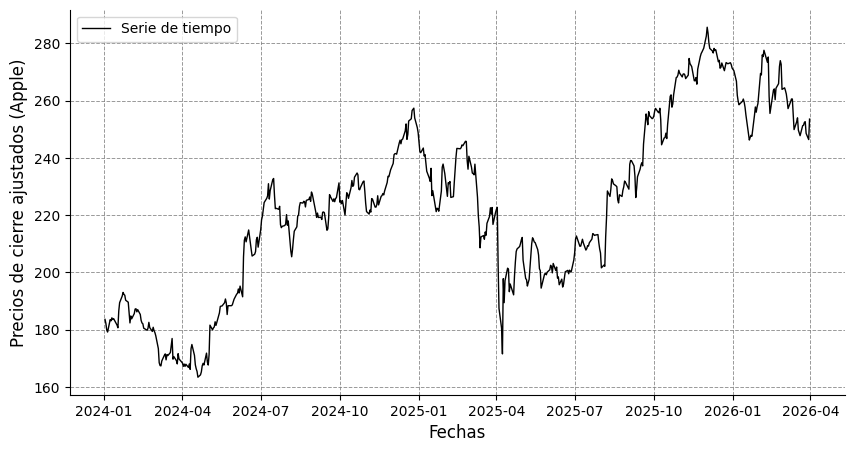

In [4]:
# @title
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(10, 5),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=100           # resolución del gráfico
)

# --- Gráfico de línea ---
plt.plot(
    x, y,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Serie de tiempo'
)

# --- Título ---
plt.title(
    '',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Fechas',
    fontsize=12
)

plt.ylabel(
    'Precios de cierre ajustados (Apple)',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)



## Métodos de promedios móviles

In [5]:
# Promedio Móvil Simple
df['SMA_21'] = df['Adj_Close_AAPL'].rolling(window=21).mean()

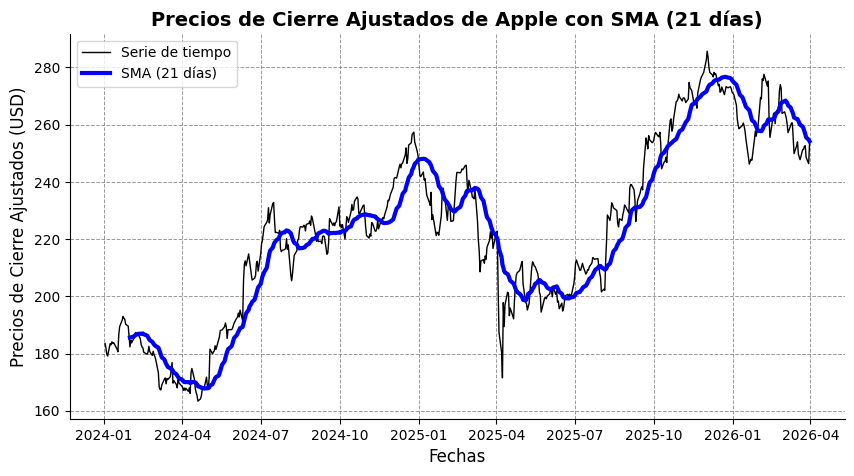

In [6]:
# @title
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(10, 5),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=100           # resolución del gráfico
)

# --- Gráfico de línea ---
plt.plot(
    x, y,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Serie de tiempo'
)

# --- Gráfico de línea ---
plt.plot(
    x, df["SMA_21"],
    color='blue',   # color de la línea
    linewidth=3.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='SMA (21 días)'
)

# --- Título ---
plt.title(
    'Precios de Cierre Ajustados de Apple con SMA (21 días)',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Fechas',
    fontsize=12
)

plt.ylabel(
    'Precios de Cierre Ajustados (USD)',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)
plt.show()


## Observaciones


---
+ Valor seleccionado: Se utilizó una ventana de 21 observaciones, equivalente a un mes operativo bursátil (excluyendo fines de semana).

Justificación:

+ Una ventana de 21 días permite un equilibrio adecuado entre la reducción del ruido diario de alta frecuencia y la retención de la dirección general de la tendencia.

+ Ventanas más cortas mantienen demasiada volatilidad y ruido, mientras que ventanas más largas generan un retraso en el método y cambia los precios.


## Método de suavisación exponencial

In [7]:
df['SES_21'] = df['Adj_Close_AAPL'].ewm(span=21, adjust=False).mean()

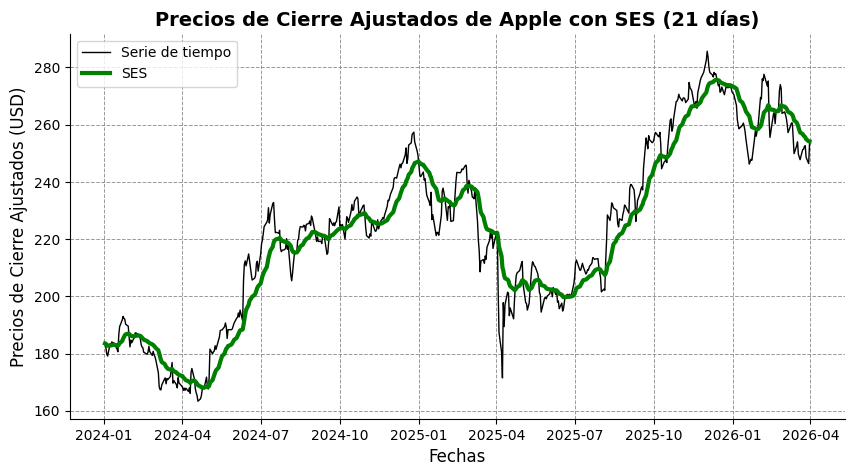

In [8]:
# @title
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(10, 5),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=100           # resolución del gráfico
)

# --- Gráfico de línea ---
plt.plot(
    x, y,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Serie de tiempo'
)

# --- Gráfico de línea ---
plt.plot(
    x, df["SES_21"],
    color='green',   # color de la línea
    linewidth=3.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='SES'
)

# --- Título ---
plt.title(
    'Precios de Cierre Ajustados de Apple con SES (21 días)',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Fechas',
    fontsize=12
)

plt.ylabel(
    'Precios de Cierre Ajustados (USD)',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)
plt.show()

## SMA

+ Ventajas: Al otorgar la misma ponderación a todas las observaciones del mes bursátil, genera una línea base muy limpia y estable que facilita la identificación visual de la tendencia general a mediano plazo de los precios de cierre de Apple.

+ Desventajas: Presenta un retraso visible frente a los puntos de inflexión más marcados y cambios de dirección repentinos en la cotización, ya que las caídas o subidas drásticas tardan en reflejarse completamente debido al promedio plano.


---


## SES
+ Ventajas: Al ponderar exponencialmente los datos, la curva verde reacciona de manera más ágil y fluida ante las fluctuaciones recientes del mercado, adaptándose con mayor precisión a los cambios de trayectoria de la acción sin perder la capacidad de filtrar el ruido diario.

+ Desventajas: Su comportamiento depende estrictamente de la correcta asignación del parámetro de suavizamientos, si no se ajusta adecuadamente al horizonte temporal de 21 observaciones, la curva puede volverse demasiado volátil o, por el contrario, perder sensibilidad ante los movimientos reales del precio.

## Tendencias no lineales

In [9]:
from numpy.polynomial.polynomial import Polynomial
X = pd.to_datetime(df["Date"]).map(pd.Timestamp.timestamp)
grado = 2
modelo = Polynomial.fit(X, y, deg = grado)
df['tendencia_polinomial'] = modelo(X)
df['ruido_polinomial'] = y - df['tendencia_polinomial']

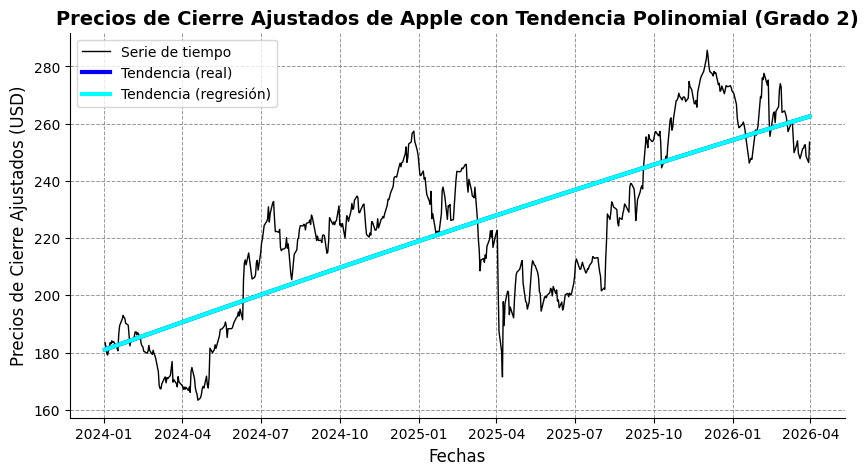

In [10]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(10, 5),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=100           # resolución del gráfico
)

# --- Gráfico de línea ---
plt.plot(
    x, df["Adj_Close_AAPL"],
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Serie de tiempo'
)
# --- Gráfico de línea ---
plt.plot(
    x, df["tendencia_polinomial"],
    color='blue',   # color de la línea
    linewidth=3.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Tendencia (real)'
)

# --- Gráfico de línea ---
plt.plot(
    x, df["tendencia_polinomial"],
    color='cyan',   # color de la línea
    linewidth=3.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Tendencia (regresión)'
)

# --- Título ---
plt.title(
    'Precios de Cierre Ajustados de Apple con Tendencia Polinomial (Grado 2)',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Fechas',
    fontsize=12
)

plt.ylabel(
    'Precios de Cierre Ajustados (USD)',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)


## Observaciones


---

+ Comportamiento: El modelo de regresión polinomial de grado 2 permite capturar de forma global la curvatura de mediano plazo de la acción, adaptándose a los cambios de aceleración de la serie de tiempo de manera más flexible que una línea recta tradicional.

+ Ruido de medición: La columna de residuos obtenida al restar la tendencia polinómica a la serie original reduce las curvas o cambios aleatorias y la volatilidad propia de la operación diaria del activo financiero.

## Análisis de los componentes de la serie

In [11]:
serie_real = df["Adj_Close_AAPL"]
serie_aproximada = df["tendencia_polinomial"] + df["ruido_polinomial"]

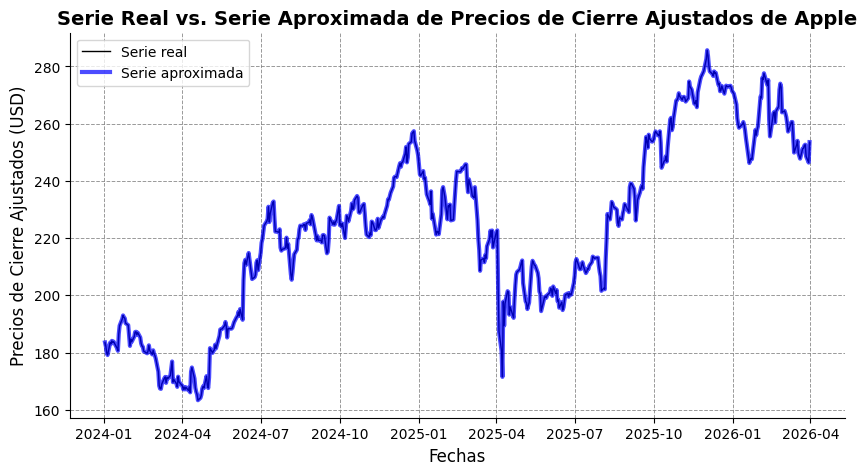

In [12]:
# @title
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(10, 5),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=100           # resolución del gráfico
)

# --- Gráfico de línea ---
plt.plot(
    x, serie_real,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Serie real'
)

# --- Gráfico de línea ---
plt.plot(
    x, serie_aproximada,
    color='blue',   # Usar un color diferente para distinguirla de la serie real
    linewidth=3.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Serie aproximada',
    alpha = 0.7 # Ajustar la transparencia para mejor visualización
)

# --- Título ---
plt.title(
    'Serie Real vs. Serie Aproximada de Precios de Cierre Ajustados de Apple',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Fechas',
    fontsize=12
)

plt.ylabel(
    'Precios de Cierre Ajustados (USD)',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)
plt.show()

In [13]:
serie_real = df["Adj_Close_AAPL"]
serie_aproximada = df["tendencia_polinomial"] + df["ruido_polinomial"]

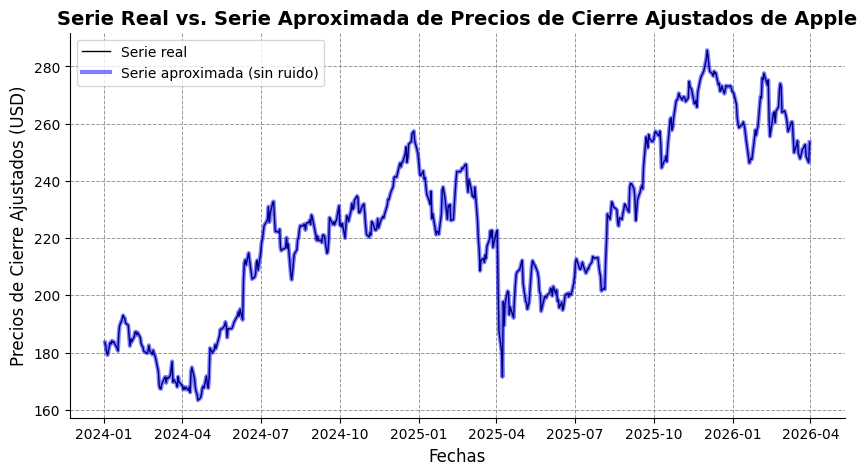

In [14]:
# @title
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(10, 5),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=100           # resolución del gráfico
)

# --- Gráfico de línea ---
plt.plot(
    x, serie_real,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Serie real'
)

# --- Gráfico de línea ---
plt.plot(
    x, serie_aproximada,
    color='blue',   # color de la línea
    linewidth=3.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Serie aproximada (sin ruido)',
    alpha = 0.5
)

# --- Título ---
plt.title(
    'Serie Real vs. Serie Aproximada de Precios de Cierre Ajustados de Apple',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Fechas',
    fontsize=12
)

plt.ylabel(
    'Precios de Cierre Ajustados (USD)',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

In [15]:
serie_real = df["Adj_Close_AAPL"]
serie_aproximada = df["tendencia_polinomial"] + df["ruido_polinomial"]

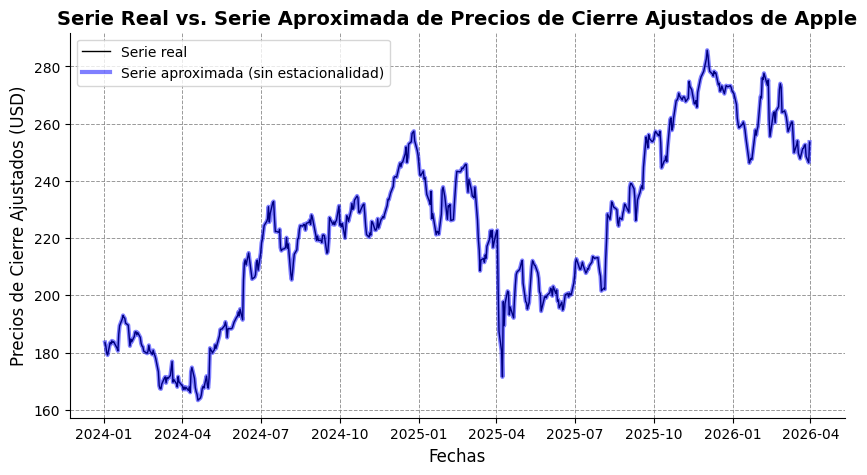

In [16]:
# @title
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(10, 5),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=100           # resolución del gráfico
)

# --- Gráfico de línea ---
plt.plot(
    x, serie_real,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Serie real'
)

# --- Gráfico de línea ---
plt.plot(
    x, serie_aproximada,
    color='blue',   # color de la línea
    linewidth=3.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Serie aproximada (sin estacionalidad)',
    alpha = 0.5
)

# --- Título ---
plt.title(
    'Serie Real vs. Serie Aproximada de Precios de Cierre Ajustados de Apple',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Fechas',
    fontsize=12
)

plt.ylabel(
    'Precios de Cierre Ajustados (USD)',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

In [17]:
serie_real = df["Adj_Close_AAPL"]
serie_aproximada = df["tendencia_polinomial"] + df["ruido_polinomial"]

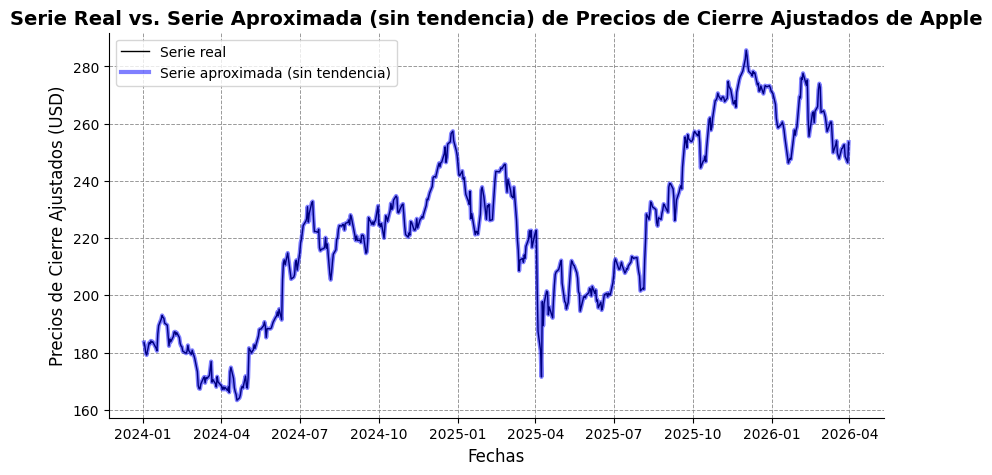

In [18]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(10, 5),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=100           # resolución del gráfico
)

# --- Gráfico de línea ---
plt.plot(
    x, serie_real,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Serie real'
)

# --- Gráfico de línea ---
plt.plot(
    x, serie_aproximada,
    color='blue',   # color de la línea
    linewidth=3.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Serie aproximada (sin tendencia)',
    alpha = 0.5
)

# --- Título ---
plt.title(
    'Serie Real vs. Serie Aproximada (sin tendencia) de Precios de Cierre Ajustados de Apple',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Fechas',
    fontsize=12
)

plt.ylabel(
    'Precios de Cierre Ajustados (USD)',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)


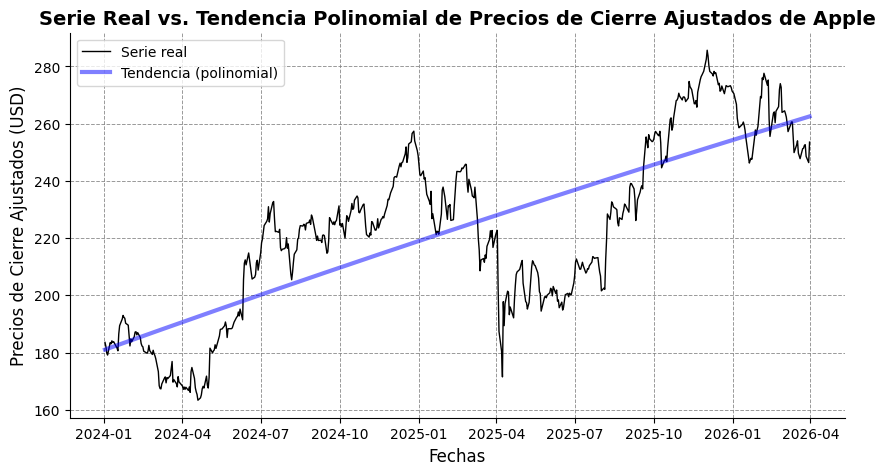

In [19]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(10, 5),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=100           # resolución del gráfico
)

# --- Gráfico de línea ---
plt.plot(
    x, df["Adj_Close_AAPL"],
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Serie real'
)

# --- Gráfico de línea ---
plt.plot(
    x, df["tendencia_polinomial"],
    color='blue',   # color de la línea
    linewidth=3.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Tendencia (polinomial)',
    alpha = 0.5
)

# --- Removing the seasonality plot as it's not yet calculated ---
# plt.plot(
#     x, df["estacionalidad_polinomial"] + df["ventas"].mean(),
#     color='red',   # color de la línea
#     linewidth=3.0,        # grosor de la línea
#     linestyle='-',        # estilo de línea
#     marker='o',           # marcador en cada punto
#     markersize=0,         # tamaño del marcador
#     markerfacecolor='white',
#     markeredgecolor='black',
#     label='Estacionalidad (polinomial)',
#     alpha = 0.5
# )

# --- Título ---
plt.title(
    'Serie Real vs. Tendencia Polinomial de Precios de Cierre Ajustados de Apple',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Fechas',
    fontsize=12
)

plt.ylabel(
    'Precios de Cierre Ajustados (USD)',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)


## Observaciones


---

En los gráficos se observa cómo la aproximación polinómica de grado 2 captura de manera global la tendencia a mediano y largo plazo de los precios de cierre ajustados de Apple. Al juntar esta tendencia, se elimina el ruido diario propio de la operación bursátil. Asimismo, al analizar los componentes se descarta la presencia de estacionalidad cíclica recurrente, enfocándose el modelo puramente en la dirección general de los datos. Por su parte, el componente residual aísla el ruido puro sin tendencia, oscilando alrededor de una media de cero para reflejar únicamente la volatilidad y las desviaciones puntuales. Finalmente, al sumar la tendencia polinómica y el ruido se logra una reconstrucción exacta de la serie original, validando la consistencia matemática de la descomposición.

## Análisis fundamental (ligero)

+ Tendencia: Lo que vemos de subida en las acciones de Apple a lo largo del tiempo se debe básicamente a que la empresa sigue creciendo, vende más servicios, saca productos nuevos que la gente compra y la buena confianza que los inversionistas le tienen.

+ Estacionalidad: Aunque en nuestro modelo no metimos ciclos fijos, en el mundo de la tecnología se nota que las ventas se mueven por épocas del año, como cuando lanzan sus nuevos teléfonos a finales de año o cuando la gente compra más en las fiestas navideñas.

+ Ruido: Todas esas subidas y bajadas locas del día a día son puro ruido del mercado. Esto pasa por noticias de último momento, sorpresas en la economía, o simplemente el humor de los inversionistas en ese preciso instante que no tienen nada que ver con el valor real de la empresa a largo plazo.

## Aplicaciones

+ Inversionistas individuales: Les sirve ver hacia dónde va la acción a largo plazo para decidir si compran o guardan su dinero sin ponerse nerviosos por las bajadas de precio del día a día. Así evitan vender por impulso y logran proteger mejor su dinero.

+ Bancos y fondos de inversión: Usan esto para separar el valor real de los precios y armar portafolios de inversión más seguros. El beneficio es que miden mejor el riesgo sin dejarse engañar por la volatilidad repentina.

+ Otras empresas de tecnología: Les ayuda a entender cómo se comporta el mercado y la confianza de la gente hacia las grandes marcas. Con esto pueden planear mejor sus propios movimientos o estrategias financieras al ver cómo reacciona el valor en diferentes épocas.